In [9]:
import torch

x = torch.tensor([1.0, 2.0, 3.0])
print("1D Tensor: \n",x)

1D Tensor: 
 tensor([1., 2., 3.])


In [10]:
y = torch.zeros((3,3))
print("2D Tensor: \n",y)

2D Tensor: 
 tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])


In [11]:
a = torch.tensor([1.0,2.0])
b = torch.tensor([4.0,3.0])

print("Element-wise addition: \n",a+b)

Element-wise addition: 
 tensor([5., 5.])


In [12]:
print("Matrix Multiplication: \n",torch.matmul(a.view(2, 1), b.view(1, 2)))


Matrix Multiplication: 
 tensor([[4., 3.],
        [8., 6.]])


In [15]:
t = torch.tensor([[1, 2, 3, 4],[5, 6, 7, 8],[9, 10, 11, 12]])
print("Original Tensor: \n",t)
print("Reshaping")
print(t.reshape(6,2))
print("Transpose",t.transpose(0,1))


Original Tensor: 
 tensor([[ 1,  2,  3,  4],
        [ 5,  6,  7,  8],
        [ 9, 10, 11, 12]])
Reshaping
tensor([[ 1,  2],
        [ 3,  4],
        [ 5,  6],
        [ 7,  8],
        [ 9, 10],
        [11, 12]])
Transpose tensor([[ 1,  5,  9],
        [ 2,  6, 10],
        [ 3,  7, 11],
        [ 4,  8, 12]])


*Practice Of backpropogation in Pytorch*


**Y= x^2+2x+5**

In [15]:
import torch
x = torch.tensor([[1.,2.,3.,5.],[4.,7.,5.,9.]],requires_grad=True)
y = x**2+2*x+5
print(y)

tensor([[  8.,  13.,  20.,  40.],
        [ 29.,  68.,  40., 104.]], grad_fn=<AddBackward0>)


In [16]:
y.sum().backward()
print(x.grad)
x.grad.zero_()

tensor([[ 4.,  6.,  8., 12.],
        [10., 16., 12., 20.]])


tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.]])

**Y= x^3+2x^2+5**

In [18]:
y = x**3+2*x**2+5
print(y)


tensor([[  8.,  21.,  50., 180.],
        [101., 446., 180., 896.]], grad_fn=<AddBackward0>)


In [19]:
y.sum().backward()
print(x.grad)
x.grad.zero_()

tensor([[  7.,  20.,  39.,  95.],
        [ 64., 175.,  95., 279.]])


tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.]])

**y=4x^2−3x+7,**

In [20]:
y= 4*x**2-3*x+7
print(y)

tensor([[  8.,  17.,  34.,  92.],
        [ 59., 182.,  92., 304.]], grad_fn=<AddBackward0>)


In [21]:
y.sum().backward()
print(x.grad)
x.grad.zero_()

tensor([[ 5., 13., 21., 37.],
        [29., 53., 37., 69.]])


tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.]])

**y=(2x+1)^2**

In [22]:
y = (2*x+1)**2
print(y)

tensor([[  9.,  25.,  49., 121.],
        [ 81., 225., 121., 361.]], grad_fn=<PowBackward0>)


In [23]:
y.sum().backward()
print(x.grad)
x.grad.zero_()

tensor([[12., 20., 28., 44.],
        [36., 60., 44., 76.]])


tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.]])

**Creating ANN with PyTorch**

In [24]:
import pandas as pd 
import numpy as np

data = pd.read_csv("C:\\Study content\\ML\\DATASETS\\diabetes.csv")
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [25]:
data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [26]:
from sklearn.model_selection import train_test_split 

X = data.drop("Outcome",axis=1).values
y = data["Outcome"].values


In [27]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
y_train = torch.FloatTensor(y_train)
y_test = torch.FloatTensor(y_test)


In [28]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [31]:
data.shape

(768, 9)

In [32]:
# Main ANN
class ANN(nn.Module):
    def __init__(self,input_features = 8,hidden1 = 20, hidden2 = 20, output_features = 2):
        super().__init__()
        self.f_connected1 = nn.Linear(input_features,hidden1)
        self.f_connected2 = nn.Linear(hidden1,hidden2)
        self.out = nn.Linear(hidden2,output_features)
    def forward(self,x):
        x = F.relu(self.f_connected1(x))
        x = F.relu(self.f_connected2(x))
        x = self.out(x)
        return x



In [33]:
import torch.optim as optim
torch.manual_seed(20)
model = ANN()

In [35]:
model.parameters

<bound method Module.parameters of ANN(
  (f_connected1): Linear(in_features=8, out_features=20, bias=True)
  (f_connected2): Linear(in_features=20, out_features=20, bias=True)
  (out): Linear(in_features=20, out_features=2, bias=True)
)>

In [40]:
loss_function = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=0.01)
final_losses = []

In [41]:
epochs = 1000
for i in range(epochs):
    y_pred = model.forward(X_train)
    loss = loss_function(y_pred,y_train.long())
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    final_losses.append(loss.item())

    if i%10==0:
        print(f"Epoch: {i}, Loss: {loss.item()}")

Epoch: 0, Loss: 0.14792291820049286
Epoch: 10, Loss: 0.7271899580955505
Epoch: 20, Loss: 0.6296623945236206
Epoch: 30, Loss: 0.39709219336509705
Epoch: 40, Loss: 0.3325487971305847
Epoch: 50, Loss: 0.2943427264690399
Epoch: 60, Loss: 0.2764437198638916
Epoch: 70, Loss: 0.26531660556793213
Epoch: 80, Loss: 0.2547084093093872
Epoch: 90, Loss: 0.24610313773155212
Epoch: 100, Loss: 0.23902387917041779
Epoch: 110, Loss: 0.23362885415554047
Epoch: 120, Loss: 0.22863444685935974
Epoch: 130, Loss: 0.22362853586673737
Epoch: 140, Loss: 0.21970337629318237
Epoch: 150, Loss: 0.21635384857654572
Epoch: 160, Loss: 0.2133760303258896
Epoch: 170, Loss: 0.21071982383728027
Epoch: 180, Loss: 0.20787450671195984
Epoch: 190, Loss: 0.20499205589294434
Epoch: 200, Loss: 0.20203138887882233
Epoch: 210, Loss: 0.19869239628314972
Epoch: 220, Loss: 0.19375240802764893
Epoch: 230, Loss: 0.18931147456169128
Epoch: 240, Loss: 0.18254590034484863
Epoch: 250, Loss: 0.1786753535270691
Epoch: 260, Loss: 0.17542690038

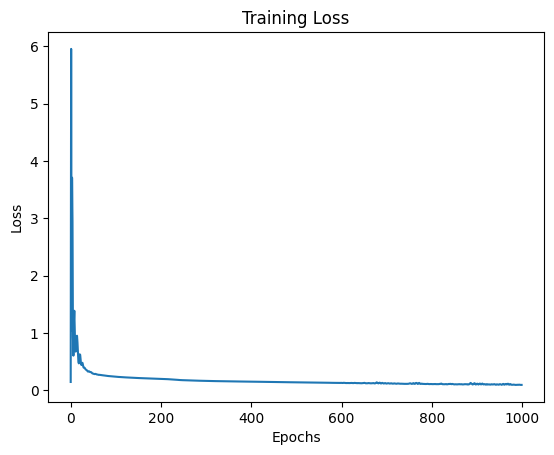

In [42]:
import matplotlib.pyplot as plt

plt.plot(range(epochs),final_losses)
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.title("Training Loss")
plt.show()

In [44]:
predictions = []
with torch.no_grad():
    for i,data in enumerate(X_test):
        y_val = model(data)
        predictions.append(y_val.argmax().item())
        print(f"Predicted: {y_val.argmax().item()}, Actual: {y_test[i].item()}")

Predicted: 1, Actual: 0.0
Predicted: 0, Actual: 0.0
Predicted: 0, Actual: 0.0
Predicted: 0, Actual: 0.0
Predicted: 0, Actual: 0.0
Predicted: 1, Actual: 0.0
Predicted: 0, Actual: 0.0
Predicted: 0, Actual: 0.0
Predicted: 1, Actual: 0.0
Predicted: 0, Actual: 0.0
Predicted: 1, Actual: 1.0
Predicted: 0, Actual: 0.0
Predicted: 1, Actual: 1.0
Predicted: 0, Actual: 0.0
Predicted: 0, Actual: 0.0
Predicted: 1, Actual: 1.0
Predicted: 0, Actual: 0.0
Predicted: 0, Actual: 0.0
Predicted: 1, Actual: 1.0
Predicted: 1, Actual: 1.0
Predicted: 0, Actual: 0.0
Predicted: 0, Actual: 0.0
Predicted: 0, Actual: 0.0
Predicted: 0, Actual: 0.0
Predicted: 0, Actual: 0.0
Predicted: 1, Actual: 1.0
Predicted: 0, Actual: 0.0
Predicted: 0, Actual: 0.0
Predicted: 0, Actual: 1.0
Predicted: 0, Actual: 0.0
Predicted: 1, Actual: 1.0
Predicted: 1, Actual: 1.0
Predicted: 1, Actual: 1.0
Predicted: 1, Actual: 1.0
Predicted: 0, Actual: 0.0
Predicted: 1, Actual: 1.0
Predicted: 0, Actual: 1.0
Predicted: 1, Actual: 1.0
Predicted: 0

              precision    recall  f1-score   support

         0.0       0.83      0.87      0.85        99
         1.0       0.75      0.69      0.72        55

    accuracy                           0.81       154
   macro avg       0.79      0.78      0.78       154
weighted avg       0.80      0.81      0.80       154

[[86 13]
 [17 38]]


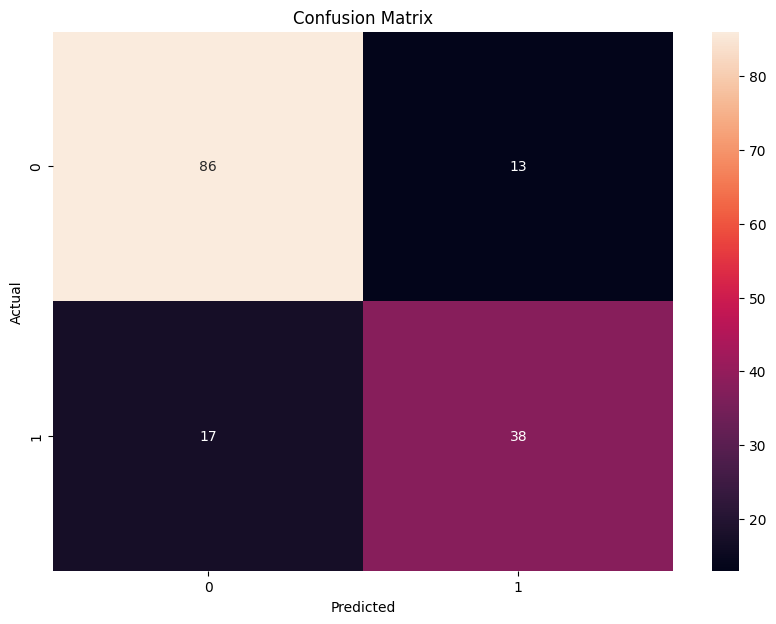

In [45]:
from sklearn.metrics import classification_report,confusion_matrix
import seaborn as sns
print(classification_report(y_test, predictions))
print(confusion_matrix(y_test, predictions))

plt.figure(figsize=(10,7))
sns = sns.heatmap(confusion_matrix(y_test, predictions),annot=True)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [46]:
torch.save(model,"C:\\Study content\\ML\\DL\\ANN_model.pt")

In [49]:
model = torch.load(
    "C:\\Study content\\ML\\DL\\ANN_model.pt",
    weights_only=False,
    map_location="cpu"
)

model.eval()

ANN(
  (f_connected1): Linear(in_features=8, out_features=20, bias=True)
  (f_connected2): Linear(in_features=20, out_features=20, bias=True)
  (out): Linear(in_features=20, out_features=2, bias=True)
)